## Feature_Selection
- Feature_selection (특성에 대한 선택) 피처선택
    - ML에서 모델 입력 변수 중 가장 중요한 변수를 선택해서 모델의 성능을 최적화
    - 불필요한 데이터를 제거하는 경우
    - 데이터 분석을 진행시 중요한 피처들을 확인할 수 있다.
    
- Machine Learning 관점에서 ?
    - 피처가 중요한 이유는 ML 데이터 기반 학습 ->input 당연히 중요하다! 
    - 무조건적인 Feature Selection 좋은 건 아니다. 
    - 오히려 당연한 결과 또는 왜곡된 결과를 만들 수 있다. 
    - 모델의 성능 향상 - Why? 왜 모델의 성능이 향상이 되나? 
        - 피처가 많으면 모델의 성능이 더 좋지 않을까? -> 어떤 모델과 분석 목적에 따라 다르겠지만, 피처가 너무 많으면 안 좋다. 
            - 차원의 저주
            - 해석 자체가 어렵다.
            - 과적합
            - 기타 이슈
            - 노이즈가 감소 -> 노이즈가 어떤 영향을? 
            - 차원축소 -> 차원이 많다면 어떤 의미? 축소가 된다라는 게 정말 좋은 의미인가?
            - 도메인을 통해서 피처를 잘 선택해야 한다. 
        - Feature Selection을 통해 모든 성능이 다 좋아진다? 라는 건 아닌 것 같다. 떨어질 수 있다. 
        - 적정한 기준 등은 도메인과 함께 해야 한다. 
    - 계산량 감소 -> 비용적인 측면 확실하게 좋을 수 있다.

- 데이터 분석 관점에서 ?
    - 중요한 피처를 파악하면 데이터 분석에 대한 출발점이 빠르게 확인 가능할 것
    - 내가 원하는 분석 목적에 더 빠르게 시작할 수 있다. 
    
### Filter Method (필터방식)
    - 데이터의 통계적인 특성 기반하여 중요도 평가하고 선택하는 방식
    - 상관계수 (Correlation Coefficient) : 특성과 타겟 변수간의 상관관계 제거 
    - 카이제곱 테스트 (Chi-Square Test) : 범주형 데이터 타겟과 독립성 테스를 통해서 제거 or 선택
    - 분산 (Variacne Threshold) : 분산이 너무 작은 특성을 제거 형태 방식
    
    - 제거에 대한 기준 임계점이 필요하다.
    - 임계점은 도메인과 함께 다른 피처들과 비교를 해야 한다.
    - 우리가 수업 때 하는 방식은 단순하게 값이 나오고 특정 임계점을 랜덤하게 찍어서 추출하는 형태

In [84]:
# 필요한 라이브러리 불러오기
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

- 상관계수를 통해서 피처를 선택한다는 것이 무슨의미인가?
- 독립변수와 종속변수와의 관계
- 독립변수와 독립변수 간의 관계를 보겠다

In [63]:
# X, y 독립변수와 종속변수와의 관계
np.random.seed(111)
n_samples = 1000

In [64]:
## 특성 피처를 생성
X1 = np.random.rand(n_samples) * 100
X2 = np.random.rand(n_samples) * 100
X3 = np.random.rand(n_samples) * 100
X4 = np.random.rand(n_samples) * 100
X_noise = np.random.rand(n_samples) * 100 #노이즈

# X1, X2 강하게 의존하는 형태, 나머지는 거의 영향이 없음
y = 3*X1 + 2*X2 + np.random.randn(n_samples)*10

In [65]:
df = pd.DataFrame({
    'X1' : X1,
    'X2' : X2,
    'X3' : X3,
    'X4' : X4,
    'X_noise' : X_noise,
    'y' : y
})

In [66]:
# 상관계수 확인하기
df.corr()

,X1,X2,X3,X4,X_noise,y
X1,1.000000,0.001169,-0.020710,-0.004450,0.005487,0.831148
X2,0.001169,1.000000,0.008571,-0.032957,0.055837,0.549372
X3,-0.020710,0.008571,1.000000,-0.027904,-0.079788,-0.012193
X4,-0.004450,-0.032957,-0.027904,1.000000,0.003884,-0.022084
X_noise,0.005487,0.055837,-0.079788,0.003884,1.000000,0.035962
y,0.831148,0.549372,-0.012193,-0.022084,0.035962,1.000000


In [67]:
# corr_matrix
corr_matrix = df.corr()['y'].drop('y')
corr_matrix

X1         0.831148
X2         0.549372
X3        -0.012193
X4        -0.022084
X_noise    0.035962
Name: y, dtype: float64

In [68]:
#0.5 특성만 뽑아보자!
threshold=0.5
selected_features =corr_matrix[abs(corr_matrix)>threshold].index

print(selected_features)

Index(['X1', 'X2'], dtype='object')


In [69]:
# LR
# 데이터 분할
X_selected = df[selected_features]
X_train, X_test, y_train, y_test = train_test_split(X_selected, df['y'], test_size = 0.2, random_state = 111)

# 모델학습
model = LinearRegression()
model.fit(X_train, y_train)

# 예측 MSE
y_pred = model.predict(X_test)
mse_selected = mean_squared_error(y_test, y_pred)
print('mse_selected',mse_selected)

mse_selected 94.10335912108974


In [72]:
# 전체데이터랑 비교하면
#Linear Regression
# 데이터 분할_ 선택된 피처
X_full = df.drop(columns = ['y'])
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, df['y'], test_size = 0.2, random_state = 111)

# 모델학습
model_full = LinearRegression()
model_full.fit(X_train_full, y_train_full)

#예측 MSE
y_pred_full = model_full.predict(X_test_full)
mes_full= mean_squared_error(y_test_full, y_pred_full)
print('Mse :',mes_full)

Mse : 94.29334037001023


In [74]:
94.10335912108974- 94.29334037001023

-0.18998124892048907

### 피처들과 피처들의 관계
  - 독립변수와 독립변수의 관계

In [91]:
## 특성 피처를 생성
X1 = np.random.rand(n_samples) * 100
X2 = np.random.rand(n_samples) * 100
X3 = np.random.rand(n_samples) * 100
X4 = np.random.rand(n_samples) * 100
X_noise = np.random.rand(n_samples) * 100 #노이즈

# X1, X3 강하게 의존하는 형태, 나머지는 거의 영향이 없음
y = 3*X1 + 2*X3 + np.random.randn(n_samples)*10

In [92]:
df = pd.DataFrame({
    'X1' : X1,
    'X2' : X2,
    'X3' : X3,
    'X4' : X4,
    'X_noise' : X_noise,
    'y' : y
})

In [93]:
# 상관관계를 보자
# corr_matrix

corr_matrix = df.drop(columns = ['y']).corr()
print(corr_matrix)

               X1        X2        X3        X4   X_noise
X1       1.000000  0.004154 -0.046958  0.006669  0.046827
X2       0.004154  1.000000 -0.024142 -0.009475  0.037342
X3      -0.046958 -0.024142  1.000000 -0.015483 -0.006679
X4       0.006669 -0.009475 -0.015483  1.000000  0.021044
X_noise  0.046827  0.037342 -0.006679  0.021044  1.000000


<Axes: >

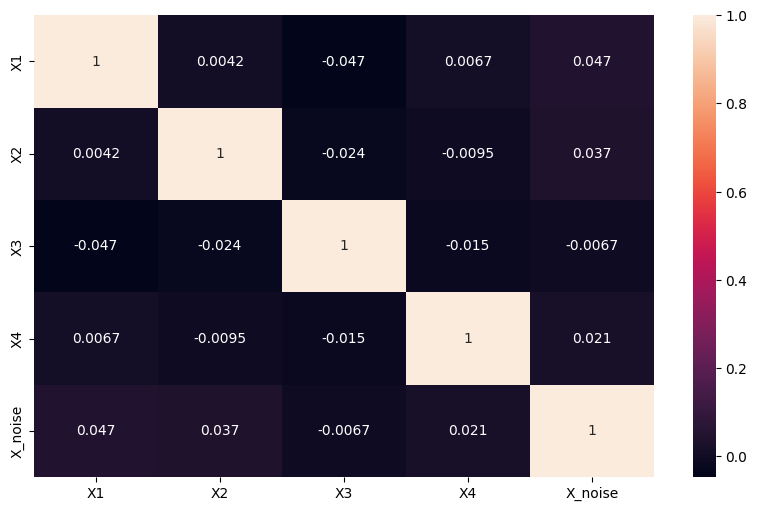

In [94]:
plt.figure(figsize = (10,6))
sns.heatmap(corr_matrix, annot = True)

In [95]:
corr_matrix

,X1,X2,X3,X4,X_noise
X1,1.000000,0.004154,-0.046958,0.006669,0.046827
X2,0.004154,1.000000,-0.024142,-0.009475,0.037342
X3,-0.046958,-0.024142,1.000000,-0.015483,-0.006679
X4,0.006669,-0.009475,-0.015483,1.000000,0.021044
X_noise,0.046827,0.037342,-0.006679,0.021044,1.000000


In [97]:
# 상관계수가 Treshold 0.8이상인 경우는 제거를 한다
# X1, X2 상관관계가 높다 -> 제거를 해야하나?
# X1, X2 상관관계가 높다 -> 같이 움직인다, X1이 증가하면 X2가 증가한다는 뜻
# 같이 움직이므로 선형회귀에서 오차 계산 등이 오차 값이 계산될 때, 더 큰 영향을 준다.
# 다중 공선성 문제라 하고 대부분 다중공선성이 높은 피처들은 제거를 한다.

treshold = 0.8
to_drop = set()

# 상관계수가 높은 피처만 출력
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i,j])>treshold:
            to_drop.add(corr_matrix.columns[i])
print(to_drop)

#원하는 피처만 제거함
X_reduced = df.drop(columns=list(to_drop)+['y'])

X_train, X_test, y_train, y_test = train_test_split(X_reduced, df['y'], test_size = 0.3, random_state = 111)

set()


In [102]:
# 상관계수가 높은 피처를 제거했을때
# 모델학습
model = LinearRegression()
model.fit(X_train, y_train)

# 예측 MSE
y_pred = model.predict(X_test)
mes_selected = mean_squared_error(y_test, y_pred)
print('MSE : ', mes_selected)

MSE :  100.86044132151846


In [103]:
## 전체 피처가 다 들어간 경우
#데이터 분할 _선택된 피처로
X_full = df.drop(columns = ['y'])
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full,df['y'],test_size=0.2,random_state=111)

#모델학습
model_full = LinearRegression()
model_full.fit(X_train_full, y_train_full)

#예측 MSE
y_pred_full =model_full.predict(X_test_full)
mse_full =mean_squared_error(y_test_full, y_pred_full)
print('mse_full',mse_full)

mse_full 105.14189274998357


### 선형회귀로 모델링

### y값과 상관관계를 보는 것은 특성 선택의 목적
 - 피처와 타겟변수 y의 상관관계를 통해서 타켓변수의 상관성이 높은 피처를 선택하는 것
 - 타겟 변수와 상관관계가 높은 피처가 있다면 -> 예측을 잘 할수 있다. 선형적인 회귀분석인데 타겟과 피처가 섢령적인데 당연히 좋은 결과가 나올 수 밖에 없음
### X 피처들 간의 상관관계를 보는 것은 다중공선성을 해결하거나, 피처를 제거하는 목적에 있음
 - 피처들간 상관관계를 통해서 두 개이상의 피처가 유사한 정보를 제공하는지 (선형성이 같이 움직이는지)
 - 다중공선성을 해결하기 위한 방법으로도 확인이 가능 -> 모델이 불안정해진다.상관계수가 높은 피처들이 같이 있으면 제대로 평가를 못하는 경우가 발생함
 - 피처에 대한 선택도 기준에 따라 제거, 선택이 가능하고, 모든 피처가 실제 성능이 다 올라가거나 떨어지는 것이 아니다
 - 피처에 대한 이해도도 중요하지만, 데이터, 도메인, 모델 이 모든 것을 다 이해하고 있어야 이 수치가 왜 이렇게 나오는지? 조금은 더 이해할 수 있음